# Transformada de Fourier
Cualquier función que se repite periódicamente puede ser expresada como la suma de senos y cosenos de diferentes frecuencias cada uno multiplicado por un  coeficiente diferente.

Este se usa para aplicar filtros para eliminar el ruido en ciertas frecuencias (altas o bajas).


## Definición (Continua)
Se define como:
$$ F(u) = \int_{\infty}^{\infty} f(x) e^{-j2\pi ux} dx $$
Transformada inversa de Fourier:
$$ f(x) = \int_{\infty}^{\infty} F(u) e^{-j2\pi ux} du $$

### Convolución y transformada de Fourier (Propiedades)
Spacial domain (x) $\iff$ Frequency domain (u):
$$ g = f*h \iff G = FH$$
$$ g = fh \iff G = F*H$$

H es un filtro (funciones que atenuan la imagen).

## Definición (Discreta)
Una función continua $f(x)$ se discretiza

Trans discreta
$$ F(u) = \frac{1}{M} \sum_{x=0}^{M-1} f(x)e^{-j2\pi ux/M} $$
Para $u = 1, 2, ..., M-1$
AntiTrans discreta
$$ F(u) = \frac{1}{M} \sum_{x=0}^{M-1} f(x)e^{-j2\pi ux/M} $$
Para $u = 1, 2, ..., M-1$

Recordando la identidad de Euler para los complejos, podemos descomponer la señal en una parte imaginario y real:
$$ F(u) = \frac{1}{M} \sum_{x=0}^{M-1} f(x)[\cos(2\pi ux/M) - j\sin(2\pi ux/M)] $$
Lo que debemos obtener para la imagen necesitamos elevar al cuadrado los términos.

La magnitud (espectro) de la imagen es:
$$ |F(u)| = [R^2(u) + I^2(u)]^{1/2} $$
El ángulo de fase del espectro viene dado por:
$$ \phi $$

Para el caso bidimensional será:
$$ F(u, v) = \sum_{x=0}^{M-1}\sum_{y=0}^{N-1} f(x, y) e^{-j2\pi(ux/M + vy/N)} $$
Para la T. Inversa:
$$ f(x, y) = \frac{1}{MN} \sum_{u=0}^{M-1}\sum_{v=0}^{N-1} F(u, v)e^{-j2\pi(ux/M + vy/N)} $$


### Operacion para que quede bien la transformada
$$ F\{(-1)^{x+y}f(x, y)\} $$
Con esto la transformada queda centrada y así se puede aplicar un filtro

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

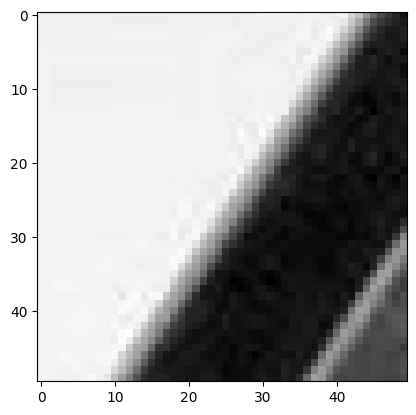

In [74]:
ruta = r'Copia de Casa con bordes.jpg' 
ima = cv2.imread(ruta)
ima = ima[250:300, 150:200, 0]# ima[200:300, 150:350, 0]
plt.imshow(ima, cmap = 'gray')
plt.show()

In [ ]:
def TF_2d_casera(imagen):
    # Sacamos las dimensiones de la imagen
    M, N = imagen.shape
    imagen = imagen.astype(float) #cambiamos el tipo de dato para hacer las operaciones
    # Creamos una matriz donde quedará la TF
    TF = np.zeros_like(imagen, dtype=complex)

    # Aplicamos la fórmula para poder hacer que la TF quede en la misma forma
    ima_cambiada = np.zeros_like(imagen)
    for y in range(M):
        for x in range(N):
            ima_cambiada[y][x] = imagen[y][x] * (-1) ** (x + y)

    # Hacemos las 4 sumatorias (las de la imagen y las de la trans)
    for v in range(M): # Fila de la imagen transformada
        for u in range(N): # Columan de la imagen transformada
            for y in range(M): # Fila en la imagen original
                for x in range(N): # Columna en la imagen original
                    # Calculamos el exponente:
                    # Para usar complejos en python usamos el formato "1j"
                    TF[v][u] += (ima_cambiada[y][x] * np.exp(-1j * 2 * np.pi * ((u * x) / N + (v * y) / M)))
    return TF


In [66]:
def ATF_2d_casera(imagen):
    # Sacamos las dimensiones de la imagen
    M, N = imagen.shape
    # Creamos una matriz donde quedará la TF
    TF = np.zeros_like(imagen, dtype=complex)
    
    # Hacemos las 4 sumatorias (las de la imagen y las de la trans)
    for v in range(M): # Fila de la imagen transformada
        for u in range(N): # Columan de la imagen transformada
            for y in range(M): # Fila en la imagen original
                for x in range(N): # Columna en la imagen original
                    # Calculamos el exponente:
                    # Para usar complejos en python usamos el formato "1j"
                    TF[v][u] += (imagen[y][x] * np.exp(1j * 2 * np.pi * ((u * x) / N + (v * y) / M)))
    return np.abs(TF / (M * N))


In [67]:
def mostrar_TF(trans):
    return np.log(np.abs(trans) + 1)

In [68]:
TF = TF_2d_casera(ima)

In [69]:
ATF = ATF_2d_casera(TF)

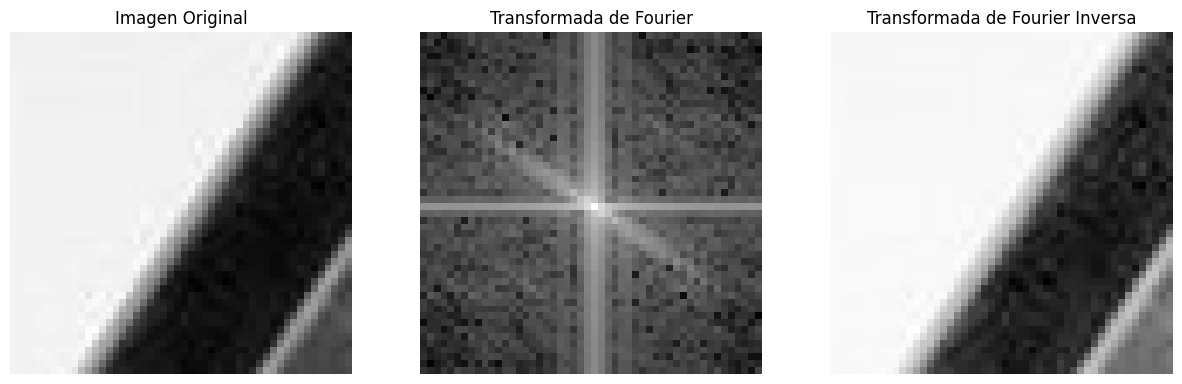

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].imshow(ima, cmap='gray')
axs[0].set_title('Imagen Original') 
axs[0].axis('off')
axs[1].imshow(mostrar_TF(TF), cmap='gray')
axs[1].set_title('Transformada de Fourier')
axs[1].axis('off')
axs[2].imshow(mostrar_TF(ATF), cmap='gray')
axs[2].set_title('Transformada de Fourier Inversa')
axs[2].axis('off')
plt.show()